In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('train.csv')
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
train.shape

(8693, 14)

In [5]:
train_label = train.copy()

In [6]:
train_label.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [7]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [8]:
train.shape

(8693, 14)

In [9]:
train_label.head(20)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [10]:
train_label['Age'].fillna(train_label['Age'].median(), inplace=True)
train_label['RoomService'].fillna(train_label['RoomService'].median(), inplace=True)
train_label['FoodCourt'].fillna(train['FoodCourt'].median(), inplace=True)
train_label['ShoppingMall'].fillna(train_label['ShoppingMall'].median(), inplace=True)
train_label['Spa'].fillna(train_label['Spa'].median(), inplace=True)
train_label['VRDeck'].fillna(train_label['VRDeck'].median(), inplace=True)

In [11]:
train_label['HomePlanet'].fillna(train_label['HomePlanet'].mode()[0], inplace=True)
train_label['Destination'].fillna(train_label['Destination'].mode()[0], inplace=True)
train_label['VIP'].fillna(train_label['VIP'].mode()[0], inplace=True)
train_label['CryoSleep'].fillna(train_label['CryoSleep'].mode()[0], inplace=True)

C:\Users\WINDOWS 11-23H2\AppData\Local\Temp\ipykernel_3888\3821827849.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_label['VIP'].fillna(train_label['VIP'].mode()[0], inplace=True)
C:\Users\WINDOWS 11-23H2\AppData\Local\Temp\ipykernel_3888\3821827849.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_label['CryoSleep'].fillna(train_label['CryoSleep'].mode()[0], inplace=True)


In [12]:
train_label['Cabin'] = train_label['Cabin'].fillna('Unknown/0/Unknown')
train_label[['Deck', 'Num', 'Side']] = train_label['Cabin'].str.split('/', expand=True)

In [13]:
train_label.isnull().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin             0
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Deck              0
Num               0
Side              0
dtype: int64

In [14]:
train_label["TotalSpend"] = (
    train_label['RoomService'] +
    train_label['FoodCourt'] +
    train_label['ShoppingMall'] +
    train_label['Spa'] +
    train_label['VRDeck']
)
train_label.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Num,Side,TotalSpend
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P,0.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S,736.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S,10383.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S,5176.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S,1091.0


In [15]:
train_label.drop(columns = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Name", "Cabin", "VIP"], inplace = True)

In [16]:
print("Train vs cryosleep = ", train["Transported"].corr(train['CryoSleep']))
print("Train vs VIP = ", train["Transported"].corr(train['VIP']))
print("Train vs RoomService = ", train["Transported"].corr(train['RoomService']))
print("Train vs FoodCourt = ", train["Transported"].corr(train['FoodCourt']))
print("Train vs ShoppingMall = ", train["Transported"].corr(train['ShoppingMall']))
print("Train vs Spa = ", train["Transported"].corr(train['Spa']))
print("Train vs VRDeck = ", train["Transported"].corr(train['VRDeck']))

Train vs cryosleep =  0.4686448608124055
Train vs VIP =  -0.0376497222591982
Train vs RoomService =  -0.24461142158527566
Train vs FoodCourt =  0.04656639376472204
Train vs ShoppingMall =  0.01014089002427718
Train vs Spa =  -0.22113134924572825
Train vs VRDeck =  -0.20707538958428992


In [17]:
train_label.isnull().sum()

PassengerId    0
HomePlanet     0
CryoSleep      0
Destination    0
Age            0
Transported    0
Deck           0
Num            0
Side           0
TotalSpend     0
dtype: int64

In [18]:
train_label.shape

(8693, 10)

In [19]:
train_label.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age',
       'Transported', 'Deck', 'Num', 'Side', 'TotalSpend'],
      dtype='object')

In [20]:
train_label = pd.get_dummies(train_label, columns=["HomePlanet", "Deck", "Side", "Destination"],drop_first=True, dtype='int')

In [21]:
train_label["CryoSleep"] = train_label["CryoSleep"].astype(int)
train_label["Transported"] = train_label["Transported"].astype(int)

In [22]:
train_label.head()

,PassengerId,CryoSleep,Age,Transported,Num,TotalSpend,HomePlanet_Europa,HomePlanet_Mars,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,Side_S,Side_Unknown,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0001_01,0,39.0,0,0,0.0,1,0,1,0,0,0,0,0,0,0,0,0,0,1
1,0002_01,0,24.0,1,0,736.0,0,0,0,0,0,0,1,0,0,0,1,0,0,1
2,0003_01,0,58.0,0,0,10383.0,1,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0003_02,0,33.0,0,0,5176.0,1,0,0,0,0,0,0,0,0,0,1,0,0,1
4,0004_01,0,16.0,1,1,1091.0,0,0,0,0,0,0,1,0,0,0,1,0,0,1


In [23]:
train_label.columns

Index(['PassengerId', 'CryoSleep', 'Age', 'Transported', 'Num', 'TotalSpend',
       'HomePlanet_Europa', 'HomePlanet_Mars', 'Deck_B', 'Deck_C', 'Deck_D',
       'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown', 'Side_S',
       'Side_Unknown', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e'],
      dtype='object')

In [24]:
train_label.shape

(8693, 20)

In [25]:
train_label_y = train_label["Transported"]
train_label_X = train_label.drop(["Transported", "PassengerId", "Num"], axis=1)
train_label_X = train_label_X.fillna(0)

In [26]:
train_label_X = pd.get_dummies(train_label_X)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_label_X, train_label_y, test_size=0.20, random_state=42)

In [28]:
from sklearn.ensemble import RandomForestClassifier

model_Rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_Rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
y_pred = model_Rf.predict(X_test)
y_pred

array([0, 0, 1, ..., 1, 1, 0], shape=(1739,))

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [31]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7078780908568143
[[630 231]
 [277 601]]
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       861
           1       0.72      0.68      0.70       878

    accuracy                           0.71      1739
   macro avg       0.71      0.71      0.71      1739
weighted avg       0.71      0.71      0.71      1739



In [32]:
from sklearn.model_selection import RandomizedSearchCV

classifier = RandomizedSearchCV(
    model_Rf,
    param_distributions={
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    n_iter=20,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2 
)

classifier.fit(train_label_X, train_label_y)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [33]:
results = pd.DataFrame(classifier.cv_results_)

In [34]:
results[['params', 'mean_test_score']]

,params,mean_test_score
0,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.736571
1,"{'n_estimators': 100, 'min_samples_split': 10,...",0.743588
2,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.746924
3,"{'n_estimators': 100, 'min_samples_split': 10,...",0.741632
4,"{'n_estimators': 100, 'min_samples_split': 10,...",0.737376
5,"{'n_estimators': 100, 'min_samples_split': 5, ...",0.746924
6,"{'n_estimators': 300, 'min_samples_split': 2, ...",0.745429
7,"{'n_estimators': 200, 'min_samples_split': 2, ...",0.743704
8,"{'n_estimators': 200, 'min_samples_split': 10,...",0.740482
9,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.747959


In [35]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


xgb_model.fit(train_label_X, train_label_y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [36]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb

array([0, 0, 1, ..., 0, 1, 0], shape=(1739,))

In [37]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
accuracy_xgb

0.7935595169637722

In [38]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.76      0.86      0.80       861
           1       0.84      0.73      0.78       878

    accuracy                           0.79      1739
   macro avg       0.80      0.79      0.79      1739
weighted avg       0.80      0.79      0.79      1739



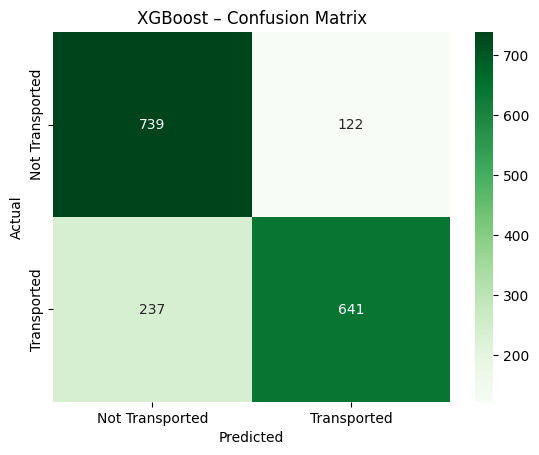

In [39]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Not Transported", "Transported"],
    yticklabels=["Not Transported", "Transported"]
)

plt.title("XGBoost – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
for t in [0.50, 0.45, 0.40, 0.35]:
    y_pred_thresh = (y_pred_xgb >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_thresh))



Threshold: 0.5
              precision    recall  f1-score   support

           0       0.76      0.86      0.80       861
           1       0.84      0.73      0.78       878

    accuracy                           0.79      1739
   macro avg       0.80      0.79      0.79      1739
weighted avg       0.80      0.79      0.79      1739


Threshold: 0.45
              precision    recall  f1-score   support

           0       0.76      0.86      0.80       861
           1       0.84      0.73      0.78       878

    accuracy                           0.79      1739
   macro avg       0.80      0.79      0.79      1739
weighted avg       0.80      0.79      0.79      1739


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.76      0.86      0.80       861
           1       0.84      0.73      0.78       878

    accuracy                           0.79      1739
   macro avg       0.80      0.79      0.79      1739
weighted avg       0.80  

In [41]:
final_threshold = 0.40

y_pred_final = (y_pred_xgb >= final_threshold).astype(int)

##  Prediction in test.csv

In [42]:
test = pd.read_csv("test.csv")
test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [43]:
test_label = test.copy()

In [44]:
test_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [45]:
test_label.shape

(4277, 13)

In [46]:
test_label.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')

In [47]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [48]:
test_label['Age'].fillna(test_label['Age'].median(), inplace=True)
test_label['RoomService'].fillna(test_label['RoomService'].median(), inplace=True)
test_label['FoodCourt'].fillna(train['FoodCourt'].median(), inplace=True)
test_label['ShoppingMall'].fillna(test_label['ShoppingMall'].median(), inplace=True)
test_label['Spa'].fillna(test_label['Spa'].median(), inplace=True)
test_label['VRDeck'].fillna(test_label['VRDeck'].median(), inplace=True)

In [49]:
test_label['HomePlanet'].fillna(test_label['HomePlanet'].mode()[0], inplace=True)
test_label['Destination'].fillna(test_label['Destination'].mode()[0], inplace=True)
test_label['VIP'].fillna(test_label['VIP'].mode()[0], inplace=True)
test_label['CryoSleep'].fillna(test_label['CryoSleep'].mode()[0], inplace=True)

C:\Users\WINDOWS 11-23H2\AppData\Local\Temp\ipykernel_3888\3245206122.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_label['VIP'].fillna(test_label['VIP'].mode()[0], inplace=True)
C:\Users\WINDOWS 11-23H2\AppData\Local\Temp\ipykernel_3888\3245206122.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_label['CryoSleep'].fillna(test_label['CryoSleep'].mode()[0], inplace=True)


In [50]:
test_label['Cabin'] = test_label['Cabin'].fillna('Unknown/0/Unknown')
test_label[['Deck', 'Num', 'Side']] = test_label['Cabin'].str.split('/', expand=True)

In [51]:
test_label.isnull().sum()

PassengerId      0
HomePlanet       0
CryoSleep        0
Cabin            0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Name            94
Deck             0
Num              0
Side             0
dtype: int64

In [52]:
test_label["TotalSpend"] = (
    test_label['RoomService'] + 
    test_label['FoodCourt'] + 
    test_label['ShoppingMall'] + 
    test_label['Spa'] + 
    test_label['VRDeck']
)
test_label.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,Num,Side,TotalSpend
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning,G,3,S,0.0
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers,F,4,S,2832.0
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus,C,0,S,0.0
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter,C,1,S,7418.0
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez,F,5,S,645.0


In [53]:
test_label.drop(columns = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "Name", "Cabin", "VIP"], inplace = True)

In [54]:
test_label.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'Deck',
       'Num', 'Side', 'TotalSpend'],
      dtype='object')

In [55]:
test_label = pd.get_dummies(test_label, columns=["HomePlanet", "Deck", "Side", "Destination"],drop_first=True, dtype='int')

In [56]:
test_label["CryoSleep"] = test_label["CryoSleep"].astype(int)

In [57]:
test_label.head()

,PassengerId,CryoSleep,Age,Num,TotalSpend,HomePlanet_Europa,HomePlanet_Mars,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,Side_S,Side_Unknown,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0013_01,1,27.0,3,0.0,0,0,0,0,0,0,0,1,0,0,1,0,0,1
1,0018_01,0,19.0,4,2832.0,0,0,0,0,0,0,1,0,0,0,1,0,0,1
2,0019_01,1,31.0,0,0.0,1,0,0,1,0,0,0,0,0,0,1,0,0,0
3,0021_01,0,38.0,1,7418.0,1,0,0,1,0,0,0,0,0,0,1,0,0,1
4,0023_01,0,20.0,5,645.0,0,0,0,0,0,0,1,0,0,0,1,0,0,1


In [58]:
X_test_model = test_label.drop(['PassengerId', 'Num'], axis=1)

In [59]:
X_test_model = pd.get_dummies(X_test_model)

In [60]:
X_test_model = X_test_model.reindex(columns=train_label_X.columns, fill_value=0)

In [61]:
y_test_proba = xgb_model.predict_proba(X_test_model)[:, 1]

In [62]:
final_threshold = 0.40
test_predictions = (y_test_proba >= final_threshold)

## Submission File

In [63]:
submission = pd.DataFrame({
    "PassengerId" : test_label["PassengerId"],
    "Transported" : test_predictions
})

In [64]:
submission.to_csv("Spaceship_titanic.csv", index = False)

In [66]:
submission["Transported"].value_counts()

Transported
True     2205
False    2072
Name: count, dtype: int64